In [1]:
!pip install tensorflow matplotlib pillow

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

from PIL import Image

In [4]:
from google.colab import files

uploaded = files.upload()

Saving CONTENT1.jpg to CONTENT1 (1).jpg
Saving STYLE.jpg to STYLE.jpg


In [7]:
def load_img(path):
    img = Image.open(path)

    max_dim = 512

    scale = max_dim / max(img.size)

    img = img.resize(
        (round(img.size[0]*scale),
         round(img.size[1]*scale))
    )

    img = np.array(img)

    img = tf.convert_to_tensor(img)

    img = tf.image.convert_image_dtype(img, tf.float32)

    img = img[tf.newaxis, :]

    return img

content_image = load_img("CONTENT1.jpg")
style_image = load_img("STYLE.jpg")

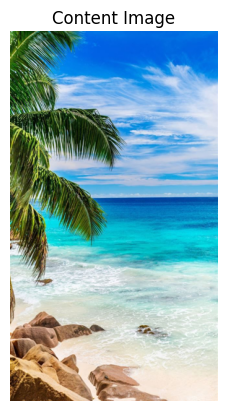

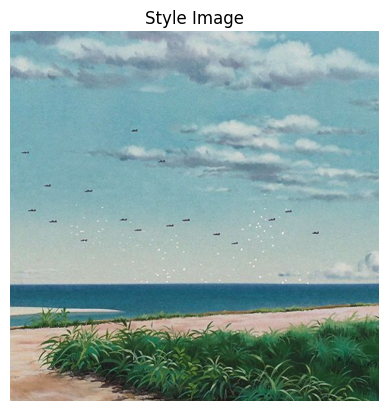

In [8]:
def show_image(img, title=None):

    img = tf.squeeze(img, axis=0)

    plt.imshow(img)

    if title:
        plt.title(title)

    plt.axis('off')
    plt.show()

show_image(content_image, "Content Image")
show_image(style_image, "Style Image")

In [9]:
vgg = VGG19(
    include_top=False,
    weights='imagenet'
)

vgg.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
content_layers = [
    'block5_conv2'
]

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [11]:
outputs = [vgg.get_layer(name).output
           for name in style_layers + content_layers]

model = tf.keras.Model(
    [vgg.input],
    outputs
)

In [12]:
def get_features(image):

    image = image * 255.0

    preprocessed = preprocess_input(image)

    outputs = model(preprocessed)

    style_outputs = outputs[:len(style_layers)]

    content_outputs = outputs[len(style_layers):]

    return style_outputs, content_outputs

In [13]:
def gram_matrix(input_tensor):

    result = tf.linalg.einsum(
        'bijc,bijd->bcd',
        input_tensor,
        input_tensor
    )

    shape = tf.shape(input_tensor)

    num_locations = tf.cast(
        shape[1]*shape[2],
        tf.float32
    )

    return result / num_locations

In [14]:
style_targets = [
    gram_matrix(style)
    for style in get_features(style_image)[0]
]

content_targets = get_features(
    content_image
)[1]

In [15]:
generated_image = tf.Variable(
    content_image
)

In [17]:
optimizer = tf.optimizers.Adam(
    learning_rate=0.02
)

style_weight = 1e-2
content_weight = 1e4


def compute_loss(image):

    style_outputs, content_outputs = \
        get_features(image)

    style_loss = 0

    for output, target in zip(
        style_outputs,
        style_targets
    ):

        style_loss += tf.reduce_mean(
            (
                gram_matrix(output)
                - target
            ) ** 2
        )

    content_loss = 0

    for output, target in zip(
        content_outputs,
        content_targets
    ):

        content_loss += tf.reduce_mean(
            (output - target) ** 2
        )

    total_loss = (
        style_weight * style_loss
        + content_weight * content_loss
    )

    return total_loss

In [18]:
@tf.function
def train_step(image):

    with tf.GradientTape() as tape:

        loss = compute_loss(image)

    grad = tape.gradient(
        loss,
        image
    )

    optimizer.apply_gradients(
        [(grad, image)]
    )

    image.assign(
        tf.clip_by_value(
            image,
            0.0,
            1.0
        )
    )

In [20]:
epochs = 3
steps_per_epoch = 10

for n in range(epochs):
    for m in range(steps_per_epoch):
        train_step(generated_image)

    print(f"Epoch {n+1} completed")

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed


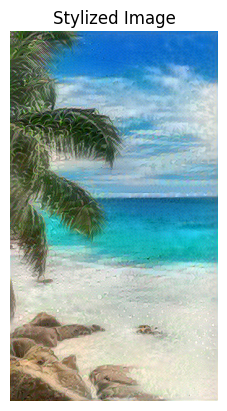

In [21]:
show_image(
    generated_image,
    "Stylized Image"
)

In [24]:
Image.fromarray(
    (tf.squeeze(generated_image, axis=0).numpy() * 255).astype(np.uint8)
).save("output.jpg")

In [25]:
files.download("output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>